<span style="font-weight:bold; font-size: 3rem; color:#333;">- Part 03: Training pipeline for Train Delay Data (Two-Stage Model)</span>

## 🗒️ Overview

This notebook downloads stored data from feature groups and uses it to train a model

It performs the following steps:

1. 


### 📝 Imports

In [1]:
import os
import datetime
import pandas as pd
import requests
import hopsworks_utils
import datetime as dt
from dotenv import load_dotenv
import hopsworks
from typing import Any, Dict, List, Optional, Tuple


# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

load_dotenv()

True

## 📡 Connect to Hopsworks Feature Store

In [2]:
# Optional: Hopsworks storage (not required)
try:
    project = hopsworks_utils.HopsworksInterface()
    print("Hopsworks login OK")
except Exception as e:
    project = None
    print("Hopsworks not configured / login failed (OK). Proceeding without it.")
    print("Reason:", repr(e))

#train_feature_df = project.get("train_stop_events_labeled")

#uncoment the below line when weather features are stored
#weather_df = project.get("weather_features") 


HOPSWORKS_API_KEY exists: True
HOPSWORKS_API_KEY length: 81
2026-01-11 16:47:51,963 INFO: Initializing external client
2026-01-11 16:47:51,965 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-01-11 16:47:53,881 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/2182
Hopsworks login OK


In [3]:
import os, json, glob
import numpy as np
import pandas as pd

from sklearn.model_selection import ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer


from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    brier_score_loss,
    mean_absolute_error, mean_squared_error
)

import joblib
import matplotlib.pyplot as plt


## 📥 Load model-ready datasets (from Part 02)

Expected files (Parquet) in the working directory (or `/mnt/data`):
- `pred_train.parquet`, `pred_val.parquet`, `pred_test.parquet`
- `react_train.parquet`, `react_val.parquet`, `react_test.parquet`

If your filenames differ, update the `PATHS` dict below.

In [4]:
import os
import pandas as pd
import json

# ---- Locate files (adjust if needed) ----
# Add "data/feature_pipeline_outputs" to this list
#CAND_DIRS = [
#    "data/feature_pipeline_outputs", 
#    "data", 
#    "."
#]

#def _find_file(name: str):
#    for d in CAND_DIRS:
#        p = os.path.join(d, name)
#        if os.path.exists(p):
#            return p
#    return None

#PATHS = {
#    "pred_train": _find_file("pred_train.parquet"),
#    "pred_val": _find_file("pred_val.parquet"),
#    "pred_test": _find_file("pred_test.parquet"),
#    "react_train": _find_file("react_train.parquet"),
#    "react_val": _find_file("react_val.parquet"),
#    "react_test": _find_file("react_test.parquet"),
#    "feature_meta": _find_file("feature_metadata.json"),
#}

#missing = [k for k,v in PATHS.items() if v is None and k != "feature_meta"]
#if missing:
#    raise FileNotFoundError(
#        "Missing required Part-02 outputs: " + ", ".join(missing) +" Make sure you ran 2_train_feature_pipeline and saved the parquet splits into /mnt/data."
#    )


#pred_train = pd.read_parquet(PATHS["pred_train"])
#pred_val   = pd.read_parquet(PATHS["pred_val"])
#pred_test  = pd.read_parquet(PATHS["pred_test"])

#react_train = pd.read_parquet(PATHS["react_train"])
#react_val   = pd.read_parquet(PATHS["react_val"])
#react_test  = pd.read_parquet(PATHS["react_test"])

pred_train = project.get("pred_train")
pred_val = project.get("pred_val")
pred_test = project.get("pred_test")

react_train = project.get("react_train")
react_val = project.get("react_val")
react_test = project.get("react_test")


print("Predictive splits:", len(pred_train), len(pred_val), len(pred_test))
print("Reactive splits:", len(react_train), len(react_val), len(react_test))

#feature_meta = None
#if PATHS["feature_meta"]:
#    with open(PATHS["feature_meta"], "r") as f:
#        feature_meta = json.load(f)
#    print("Loaded feature metadata")


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (4.84s) 
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.51s) 
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.87s) 
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.43s) 
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.09s) 
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (4.62s) 
Predictive splits: 42426 17965 10352
Reactive splits: 3629 117 10352


## 🧼 Prepare features / labels

We train:
- **Predictive (classification):** label `y_delay_within_horizon`
- **Reactive (regression):** target `additional_delay_min` (how much worse it gets from this event)

If you prefer `final_delay_min` as the reactive target, change `REACTIVE_TARGET` below.

In [5]:
#react_test = pd.read_parquet(PATHS["react_test"])
print(react_test.shape)
print(list(react_test.columns)[:20])


# Count distinct values in each column
print(react_test.nunique())



(10352, 57)
['train_run_id', 'event_time', 'station_code', 'train_id', 'activityid', 'activitytype', 'delay_min', 'is_canceled', 'deleted', 'informationowner', 'deviation', 'fromlocation', 'tolocation', 'trackatlocation', 'hour', 'dow', 'date', 'weather_temperature_2m', 'weather_precipitation', 'weather_rain']
train_run_id                            564
event_time                              546
station_code                             65
train_id                                564
activityid                            10352
activitytype                              2
delay_min                                 0
is_canceled                               2
deleted                                   1
informationowner                          6
deviation                                 4
fromlocation                            142
tolocation                              155
trackatlocation                          44
hour                                     11
dow                         

In [6]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV


PRED_LABEL = "y_delay_within_horizon"
REACTIVE_TARGET = "additional_delay_min"  # or "final_delay_min"

# Drop non-feature columns if present
NON_FEATURES_COMMON = {
    PRED_LABEL,
    "final_delay_min", "additional_delay_min", "delay_min","reason_code", "reason_text", "reason_desc", 
    "train_id", "train_run_id", "informationowner",
    "scheduled_time", "estimated_time", "actual_time", "observed_time",
    "event_time", "date","activityid"
}



def split_Xy(df: pd.DataFrame, y_col: str):
    y = df[y_col].copy()
    X = df.drop(columns=[c for c in df.columns if c in NON_FEATURES_COMMON and c != y_col], errors="ignore")
    # also ensure y removed
    X = X.drop(columns=[y_col], errors="ignore")
    return X, y

X_pred_train, y_pred_train = split_Xy(pred_train, PRED_LABEL)
X_pred_val,   y_pred_val   = split_Xy(pred_val, PRED_LABEL)
X_pred_test,  y_pred_test  = split_Xy(pred_test, PRED_LABEL)


X_re_train, y_re_train = split_Xy(react_train, REACTIVE_TARGET)
X_re_val,   y_re_val   = split_Xy(react_val, REACTIVE_TARGET)
X_re_test,  y_re_test  = split_Xy(react_test, REACTIVE_TARGET)



# --- 1. Robust Feature Type Inference ---
def infer_feature_types(X: pd.DataFrame):
    # Explicitly select all text/categorical types
    cat = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    # All remaining columns are numeric
    num = [c for c in X.columns if c not in cat]
    return cat, num

# --- 2. Clean Data (Drop problematic columns) ---
# reason_text: Free text (high cardinality) -> causes memory issues or noise
# trigger_time: Datetime objects -> crash numeric imputers
cols_to_drop = ["reason_text", "trigger_time", "weather_time"]


for df in [X_pred_train, X_pred_val, X_pred_test, X_re_train, X_re_val, X_re_test]:
    existing_drop = [c for c in cols_to_drop if c in df.columns]
    if existing_drop:
        df.drop(columns=existing_drop, inplace=True)

# Re-infer types with the fixed function
cat_pred, num_pred = infer_feature_types(X_pred_train)
cat_re,   num_re   = infer_feature_types(X_re_train)

if y_pred_test.sum() == 0:
    print("⚠️ No positive events in test set — PR-AUC undefined.")



print(f"Predictive: {len(cat_pred)} cat, {len(num_pred)} num")
print(f"Reactive:   {len(cat_re)} cat, {len(num_re)} num")

print("additional_delay_min in columns?", "additional_delay_min" in react_test.columns)


⚠️ No positive events in test set — PR-AUC undefined.
Predictive: 7 cat, 39 num
Reactive:   7 cat, 40 num
additional_delay_min in columns? True


In [7]:
display(X_pred_train)
print(X_pred_test.info())


#Print list of columns in X_pred_train
print("Columns in X_pred_train:", X_pred_train.columns.tolist())

display(y_pred_train)
print(y_pred_test.info())
print(y_pred_train.head())


display(y_re_train)
print(y_re_test.info())
print(y_re_train.head())

,station_code,activitytype,is_canceled,deleted,deviation,fromlocation,tolocation,trackatlocation,hour,dow,...,weather_precipitation_rollmean_3h,weather_rain_rollmean_3h,weather_snowfall_rollmean_3h,weather_windspeed_10m_rollmean_3h,weather_temperature_2m_rollmean_6h,weather_precipitation_rollmean_6h,weather_rain_rollmean_6h,weather_snowfall_rollmean_6h,weather_windspeed_10m_rollmean_6h,station_avg_delay
0,Arnc,Ankomst,False,False,None,Cst,U,1,0,4,...,0.0,0.0,0.0,8.400000,-2.000000,0.0,0.0,0.0,8.400000,7.970359
1,Arnc,Avgang,False,False,Kort tåg,U,Sci,2,0,4,...,0.0,0.0,0.0,8.400000,-2.000000,0.0,0.0,0.0,8.400000,7.970359
2,Arnc,Avgang,False,False,None,Sci,U,1,4,4,...,0.0,0.0,0.0,12.800000,-2.342857,0.0,0.0,0.0,10.285714,7.970359
3,Arnc,Avgang,False,False,None,U,"Sci,Söc",2,5,4,...,0.0,0.0,0.0,12.420000,-2.466667,0.0,0.0,0.0,10.633333,7.970359
4,Arnc,Avgang,False,False,None,U,"Sci,Söc",2,5,4,...,0.0,0.0,0.0,11.533333,-2.700000,0.0,0.0,0.0,10.750000,7.970359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42421,Åbe,Ankomst,False,False,None,Söc,Mr,2,16,5,...,0.0,0.0,0.0,23.297521,-5.220332,0.0,0.0,0.0,22.420747,1.969009
42422,Åbe,Avgang,False,False,None,Bål,"Äs,Nyc",3,16,5,...,0.0,0.0,0.0,23.308333,-5.187500,0.0,0.0,0.0,22.479167,1.969009
42423,Åbe,Avgang,False,False,None,Nyc,"Sci,Bål",2,16,5,...,0.0,0.0,0.0,23.313333,-5.170000,0.0,0.0,0.0,22.510000,1.969009
42424,Åbe,Avgang,False,False,None,Mr,"Äs,Söc",3,16,5,...,0.0,0.0,0.0,23.322314,-5.133195,0.0,0.0,0.0,22.574274,1.969009


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10352 entries, 0 to 10351
Data columns (total 46 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   station_code                        10352 non-null  object 
 1   activitytype                        10352 non-null  object 
 2   is_canceled                         10352 non-null  bool   
 3   deleted                             10352 non-null  bool   
 4   deviation                           87 non-null     object 
 5   fromlocation                        10352 non-null  object 
 6   tolocation                          10352 non-null  object 
 7   trackatlocation                     10352 non-null  object 
 8   hour                                10352 non-null  int32  
 9   dow                                 10352 non-null  int32  
 10  weather_temperature_2m              10352 non-null  float64
 11  weather_precipitation               10352

0        0
1        0
2        0
3        0
4        0
        ..
42421    0
42422    0
42423    0
42424    0
42425    0
Name: y_delay_within_horizon, Length: 42426, dtype: int64

<class 'pandas.core.series.Series'>
RangeIndex: 10352 entries, 0 to 10351
Series name: y_delay_within_horizon
Non-Null Count  Dtype
--------------  -----
10352 non-null  int64
dtypes: int64(1)
memory usage: 81.0 KB
None
0    0
1    0
2    0
3    0
4    0
Name: y_delay_within_horizon, dtype: int64


0      -15.0
1      -24.0
2      -25.0
3       -1.0
4        2.0
        ... 
3624   -22.0
3625   -10.0
3626   -12.0
3627     3.0
3628     2.0
Name: additional_delay_min, Length: 3629, dtype: float64

<class 'pandas.core.series.Series'>
RangeIndex: 10352 entries, 0 to 10351
Series name: additional_delay_min
Non-Null Count  Dtype  
--------------  -----  
0 non-null      float64
dtypes: float64(1)
memory usage: 81.0 KB
None
0   -15.0
1   -24.0
2   -25.0
3    -1.0
4     2.0
Name: additional_delay_min, dtype: float64


## 🧱 Preprocessing pipeline

- Impute missing values
- One-hot encode categoricals

We set `sparse_output=False` to keep downstream models simple (dense matrices).

In [12]:
# ============================================================
# Reactive model training (2 parts combined)
# - Part A: Clean reactive data + define prep_re
# - Part B: Baseline + tune point model + train quantiles + save bundle
#
# Assumes you already have:
#   X_re_train, X_re_val, X_re_test (DataFrames)
#   y_re_train, y_re_val, y_re_test (Series/arrays)
#   REACTIVE_TARGET (string, for logging/plots)
# ============================================================

import os
import json
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib


# ============================
# Part A) Clean + prep_re
# ============================

def enforce_types(df, cat_cols, num_cols):
    df_out = df.copy()

    # categorical -> string
    for c in cat_cols:
        if c in df_out.columns:
            df_out[c] = df_out[c].astype(str).replace({"nan": np.nan, "None": np.nan})

    # numeric -> float (coerce errors to NaN)
    for c in num_cols:
        if c in df_out.columns:
            df_out[c] = pd.to_numeric(df_out[c], errors="coerce")

    return df_out


print("Reactive split sizes:")
print("  train:", len(X_re_train), "val:", len(X_re_val), "test:", len(X_re_test))

# Infer cat/num from TRAIN (only)
cat_re = X_re_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_re = [c for c in X_re_train.columns if c not in cat_re]

print("Sanitizing reactive data...")
X_re_train_clean = enforce_types(X_re_train, cat_re, num_re)
X_re_val_clean   = enforce_types(X_re_val,   cat_re, num_re)
X_re_test_clean  = enforce_types(X_re_test,  cat_re, num_re)

print(f"Reactive cleaned! Cat: {len(cat_re)}, Num: {len(num_re)}")

# Version-safe OHE
try:
    ohe_re = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_re = OneHotEncoder(handle_unknown="ignore", sparse=False)

prep_re = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", ohe_re),
        ]), cat_re),
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
        ]), num_re),
    ],
    remainder="drop",
)


# ============================
# Part B) Train + evaluate + save
# ============================

# Choose eval split (TEST if possible else VAL)
if True:#len(X_re_test_clean) == 0:
    print("⚠️ Reactive TEST split is empty. Using VAL for evaluation.")
    X_eval, y_eval = X_re_val_clean, y_re_val
    eval_name = "VAL"
else:
    X_eval, y_eval = X_re_test_clean, y_re_test
    eval_name = "TEST"

if len(X_eval) == 0:
    raise ValueError("Both reactive TEST and VAL are empty. Check split + delay threshold.")


# --- Baseline (median) ---
print("\nTraining Baseline Regressor (median)...")
base_re = Pipeline([
    ("prep", prep_re),
    ("reg", DummyRegressor(strategy="median")),
])

base_re.fit(X_re_train_clean, y_re_train)
base_pred = base_re.predict(X_eval)


base_mae = mean_absolute_error(y_eval, base_pred)
base_rmse = np.sqrt(mean_squared_error(y_eval, base_pred))

print(f"✅ Baseline ({eval_name}) MAE: {base_mae:.3f}")
print(f"✅ Baseline ({eval_name}) RMSE: {base_rmse:.3f}")


# --- Tune point model (VAL) ---
print("\nTuning GradientBoostingRegressor (point model)...")

param_grid = {
    "reg__n_estimators": [200, 400],
    "reg__learning_rate": [0.05, 0.1],
    "reg__max_depth": [2, 3],
}

best_re_point = None
best_mae = np.inf
best_params = None

for params in ParameterGrid(param_grid):
    model = Pipeline([
        ("prep", prep_re),
        ("reg", GradientBoostingRegressor(
            loss="squared_error",
            random_state=42,
            n_estimators=params["reg__n_estimators"],
            learning_rate=params["reg__learning_rate"],
            max_depth=params["reg__max_depth"],
        )),
    ])

    model.fit(X_re_train_clean, y_re_train)

    # Always tune on VAL (even if TEST exists)
    if len(X_re_val_clean) == 0:
        raise ValueError("Reactive VAL split is empty; cannot tune. Adjust your split in file 2.")

    pred_val = model.predict(X_re_val_clean)
    mae_val = mean_absolute_error(y_re_val, pred_val)

    print(f"Params: {params} | Val MAE: {mae_val:.4f}")

    if mae_val < best_mae:
        best_mae = mae_val
        best_re_point = model
        best_params = params

print(f"\nBest Val MAE: {best_mae:.4f} with params: {best_params}")
"""
# Evaluate best point model on chosen eval split
p_point = best_re_point.predict(X_eval)
mae = mean_absolute_error(y_eval, p_point)
rmse = np.sqrt(mean_squared_error(y_eval, p_point))

print(f"\nPoint model ({eval_name}) MAE: {mae:.3f}")
print(f"Point model ({eval_name}) RMSE: {rmse:.3f}")


# --- Train quantiles using best params ---
print("\nTraining Quantile Regressors (P10, P50, P90) using best params...")

common = dict(
    random_state=42,
    n_estimators=best_params["reg__n_estimators"],
    learning_rate=best_params["reg__learning_rate"],
    max_depth=best_params["reg__max_depth"],
)

re_q10 = Pipeline([
    ("prep", prep_re),
    ("reg", GradientBoostingRegressor(loss="quantile", alpha=0.10, **common)),
])
re_q50 = Pipeline([
    ("prep", prep_re),
    ("reg", GradientBoostingRegressor(loss="quantile", alpha=0.50, **common)),
])
re_q90 = Pipeline([
    ("prep", prep_re),
    ("reg", GradientBoostingRegressor(loss="quantile", alpha=0.90, **common)),
])

re_q10.fit(X_re_train_clean, y_re_train)
re_q50.fit(X_re_train_clean, y_re_train)
re_q90.fit(X_re_train_clean, y_re_train)

q10 = re_q10.predict(X_eval)
q50 = re_q50.predict(X_eval)
q90 = re_q90.predict(X_eval)

# Optional clamp so intervals don't cross
q10c = np.minimum(q10, q50)
q90c = np.maximum(q90, q50)

covered_80 = np.mean((y_eval >= q10c) & (y_eval <= q90c))
print(f"Quantiles ({eval_name}) 80% coverage (P10..P90, clamped): {covered_80:.3f}")


# --- Save bundle for inference (file 4) ---
os.makedirs("data/models", exist_ok=True)

react_bundle = {
    "point": best_re_point,
    "q10": re_q10,
    "q50": re_q50,
    "q90": re_q90,
    "baseline": base_re,
    "best_params": best_params,
    "eval_split": eval_name,
    "metric_val_mae": float(best_mae),
    "target": globals().get("REACTIVE_TARGET", "unknown"),
}

bundle_path = "data/models/reactive_model.pkl"
joblib.dump(react_bundle, bundle_path)
print("✅ Saved:", bundle_path)

meta_path = "data/models/reactive_meta.json"
with open(meta_path, "w") as f:
    json.dump({
        "best_params": best_params,
        "best_val_mae": float(best_mae),
        "eval_split_used_for_reporting": eval_name,
        "train_rows": int(len(X_re_train_clean)),
        "val_rows": int(len(X_re_val_clean)),
        "test_rows": int(len(X_re_test_clean)),
        "target": globals().get("REACTIVE_TARGET", "unknown"),
    }, f, indent=2)
print("✅ Saved:", meta_path)
"""






Reactive split sizes:
  train: 3629 val: 117 test: 10352
Sanitizing reactive data...
Reactive cleaned! Cat: 7, Num: 40
⚠️ Reactive TEST split is empty. Using VAL for evaluation.

Training Baseline Regressor (median)...
✅ Baseline (VAL) MAE: 6.667
✅ Baseline (VAL) RMSE: 7.631

Tuning GradientBoostingRegressor (point model)...
Params: {'reg__learning_rate': 0.05, 'reg__max_depth': 2, 'reg__n_estimators': 200} | Val MAE: 7.1080
Params: {'reg__learning_rate': 0.05, 'reg__max_depth': 2, 'reg__n_estimators': 400} | Val MAE: 7.2678
Params: {'reg__learning_rate': 0.05, 'reg__max_depth': 3, 'reg__n_estimators': 200} | Val MAE: 6.2583
Params: {'reg__learning_rate': 0.05, 'reg__max_depth': 3, 'reg__n_estimators': 400} | Val MAE: 6.2544
Params: {'reg__learning_rate': 0.1, 'reg__max_depth': 2, 'reg__n_estimators': 200} | Val MAE: 7.2187
Params: {'reg__learning_rate': 0.1, 'reg__max_depth': 2, 'reg__n_estimators': 400} | Val MAE: 6.8186
Params: {'reg__learning_rate': 0.1, 'reg__max_depth': 3, 'reg__

'\n# Evaluate best point model on chosen eval split\np_point = best_re_point.predict(X_eval)\nmae = mean_absolute_error(y_eval, p_point)\nrmse = np.sqrt(mean_squared_error(y_eval, p_point))\n\nprint(f"\nPoint model ({eval_name}) MAE: {mae:.3f}")\nprint(f"Point model ({eval_name}) RMSE: {rmse:.3f}")\n\n\n# --- Train quantiles using best params ---\nprint("\nTraining Quantile Regressors (P10, P50, P90) using best params...")\n\ncommon = dict(\n    random_state=42,\n    n_estimators=best_params["reg__n_estimators"],\n    learning_rate=best_params["reg__learning_rate"],\n    max_depth=best_params["reg__max_depth"],\n)\n\nre_q10 = Pipeline([\n    ("prep", prep_re),\n    ("reg", GradientBoostingRegressor(loss="quantile", alpha=0.10, **common)),\n])\nre_q50 = Pipeline([\n    ("prep", prep_re),\n    ("reg", GradientBoostingRegressor(loss="quantile", alpha=0.50, **common)),\n])\nre_q90 = Pipeline([\n    ("prep", prep_re),\n    ("reg", GradientBoostingRegressor(loss="quantile", alpha=0.90, **com

In [13]:
import os, json
import numpy as np
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV


# ----------------------------
# 0) Type enforcement (same as before)
# ----------------------------
def enforce_types(df, cat_cols, num_cols):
    df_out = df.copy()

    for c in cat_cols:
        if c in df_out.columns:
            df_out[c] = df_out[c].astype(str).replace({"nan": np.nan, "None": np.nan})

    for c in num_cols:
        if c in df_out.columns:
            df_out[c] = pd.to_numeric(df_out[c], errors="coerce")

    return df_out


# ----------------------------
# 1) Clean predictive splits
# ----------------------------
print("Predictive split sizes:")
print("  train:", len(X_pred_train), "val:", len(X_pred_val), "test:", len(X_pred_test))

cat_pred = X_pred_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_pred = [c for c in X_pred_train.columns if c not in cat_pred]

print("Sanitizing predictive data...")
X_pred_train_clean = enforce_types(X_pred_train, cat_pred, num_pred)
X_pred_val_clean   = enforce_types(X_pred_val,   cat_pred, num_pred)
X_pred_test_clean  = enforce_types(X_pred_test,  cat_pred, num_pred)

print(f"Predictive cleaned! Cat: {len(cat_pred)}, Num: {len(num_pred)}")


# ----------------------------
# 2) Define preprocessor (prep_pred)
# ----------------------------
try:
    ohe_pred = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_pred = OneHotEncoder(handle_unknown="ignore", sparse=False)

prep_pred = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", ohe_pred),
        ]), cat_pred),
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
        ]), num_pred),
    ],
    remainder="drop",
)


# ----------------------------
# 3) Baseline classifier
# ----------------------------

print("\nTraining baseline LogisticRegression...")
base_clf = Pipeline([
    ("prep", prep_pred),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced")),
])
base_clf.fit(X_pred_train_clean, y_pred_train)

base_val_proba = base_clf.predict_proba(X_pred_val_clean)[:, 1]
base_val_ap = average_precision_score(y_pred_val, base_val_proba) if len(np.unique(y_pred_val)) > 1 else np.nan
print(f"✅ Baseline Val AP: {base_val_ap:.4f}")


# ----------------------------
# 4) Tune main classifier on VAL (AP)
# ----------------------------
print("\nTuning GradientBoostingClassifier...")
param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
}

best_model = None
best_ap = -np.inf
best_params = None

for p in ParameterGrid(param_grid):
    model = Pipeline([
        ("prep", prep_pred),
        ("clf", GradientBoostingClassifier(
            random_state=42,
            n_estimators=p["n_estimators"],
            learning_rate=p["learning_rate"],
            max_depth=p["max_depth"],
        )),
    ])
    model.fit(X_pred_train_clean, y_pred_train)

    val_proba = model.predict_proba(X_pred_val_clean)[:, 1]
    ap = average_precision_score(y_pred_val, val_proba) if len(np.unique(y_pred_val)) > 1 else np.nan
    print(f"Params: {p} | Val AP: {ap:.4f}")

    if np.isfinite(ap) and ap > best_ap:
        best_ap = ap
        best_model = model
        best_params = p

print(f"\nBest Val AP: {best_ap:.4f} with params: {best_params}")


# ----------------------------
# 5) Calibrate on VAL (isotonic) + evaluate
# ----------------------------
print("\nCalibrating best model (isotonic on VAL)...")
calibrator = CalibratedClassifierCV(best_model, method="isotonic", cv="prefit")
calibrator.fit(X_pred_val_clean, y_pred_val)

# choose eval split: TEST if exists else VAL
if len(X_pred_test_clean) == 0:
    print("⚠️ Predictive TEST split is empty. Evaluating on VAL instead.")
    X_eval, y_eval, eval_name = X_pred_val_clean, y_pred_val, "VAL"
else:
    X_eval, y_eval, eval_name = X_pred_test_clean, y_pred_test, "TEST"

proba = calibrator.predict_proba(X_eval)[:, 1]

ap_eval = average_precision_score(y_eval, proba) if len(np.unique(y_eval)) > 1 else np.nan
brier = brier_score_loss(y_eval, proba)

print(f"\nPredictive ({eval_name}) AP: {ap_eval:.4f}")
print(f"Predictive ({eval_name}) Brier: {brier:.4f}")


# ----------------------------
# 6) Save artifacts for file 4
# ----------------------------
os.makedirs("data/models", exist_ok=True)

joblib.dump(base_clf, "data/models/predictive_baseline.pkl")
joblib.dump(best_model, "data/models/predictive_model.pkl")
joblib.dump(calibrator, "data/models/predictive_calibrator.pkl")

with open("data/models/predictive_meta.json", "w") as f:
    json.dump({
        "best_params": best_params,
        "best_val_ap": float(best_ap),
        "eval_split_used_for_reporting": eval_name,
        "eval_ap": float(ap_eval) if np.isfinite(ap_eval) else None,
        "eval_brier": float(brier),
        "train_rows": int(len(X_pred_train_clean)),
        "val_rows": int(len(X_pred_val_clean)),
        "test_rows": int(len(X_pred_test_clean)),
        "n_cat": int(len(cat_pred)),
        "n_num": int(len(num_pred)),
    }, f, indent=2)

print("✅ Saved predictive artifacts in data/models/")


Predictive split sizes:
  train: 42426 val: 17965 test: 10352
Sanitizing predictive data...
Predictive cleaned! Cat: 7, Num: 39

Training baseline LogisticRegression...
✅ Baseline Val AP: 0.0930

Tuning GradientBoostingClassifier...
Params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200} | Val AP: 0.3665
Params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 400} | Val AP: 0.3649
Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200} | Val AP: 0.3730
Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400} | Val AP: 0.3795
Params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200} | Val AP: 0.3587
Params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 400} | Val AP: 0.3382
Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200} | Val AP: 0.3668
Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400} | Val AP: 0.3717

Best Val AP: 0.3795 with params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estima

håll koll på deviation, innehåller reason for delay
                               feature  importance
612                 lag1_delay_station    0.323915
264                    fromlocation_Mr    0.070255
615        roll_mean_delay_station_30m    0.057950
614   roll_cnt_delay_ge_10_station_15m    0.054649
98                  deviation_Kort tåg    0.052747
289                   fromlocation_Söc    0.037628
613        roll_mean_delay_station_15m    0.028656
623  weather_precipitation_rollmean_6h    0.024080
621  weather_windspeed_10m_rollmean_3h    0.021745
75                deviation_Fordonsfel    0.018430


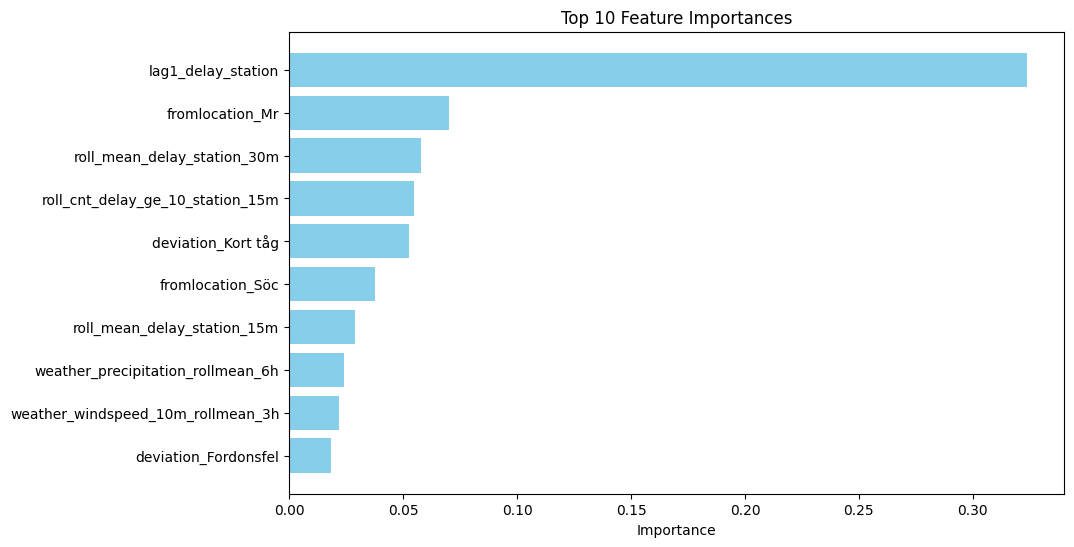

In [14]:
# Check Feature Importance
clf = best_model.named_steps["clf"]
importances = clf.feature_importances_

# Get feature names from the preprocessor
# (This is a bit tricky with Pipelines, but we can approximate)
# Note: This assumes numerical features come after categorical in the transformer output
feature_names = (best_model.named_steps["prep"]
                 .transformers_[0][1] # The categorical pipeline
                 .named_steps["ohe"]
                 .get_feature_names_out(cat_pred).tolist() 
                 + num_pred)

# Create a dataframe
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
print("håll koll på deviation, innehåller reason for delay")
print(imp_df.sort_values("importance", ascending=False).head(10))



# Plot top 10 features
top_features = imp_df.sort_values("importance", ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"], color='skyblue')
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.savefig("docs/assets/img/feature_importances.png", bbox_inches='tight')
plt.gca().invert_yaxis()


plt.show()


## 1) Predictive model (risk): baselines + main + calibration

We train:
- Baseline: Logistic Regression
- Main: Gradient Boosting Classifier

Then calibrate using **isotonic** on the validation split (time-based).

## 💾 Persist artifacts

We save:
- `predictive_model.pkl` (best uncalibrated pipeline)
- `calibrator.pkl` (isotonic calibrator wrapping the predictive model)
- `reactive_model.pkl` (dict containing point + quantile pipelines)
- `metrics.json` + plots

In [23]:
import os
import json
import joblib
import numpy as np

ART_DIR = "data/models"
os.makedirs(ART_DIR, exist_ok=True)

# ----------------------------
# 1) Save predictive artifacts
# ----------------------------
predictive_model_path = os.path.join(ART_DIR, "predictive_model.pkl")
calibrator_path       = os.path.join(ART_DIR, "calibrator.pkl")

joblib.dump(best_model, predictive_model_path)
joblib.dump(calibrator, calibrator_path)

# ----------------------------
# 2) Save reactive artifacts
# ----------------------------
#reactive_bundle = {
  #  "point": re_point,
 #   "q10": re_q10,
#    "q50": re_q50,
#    "q90": re_q90,
#    "target": REACTIVE_TARGET,
#}

reactive_bundle = {
    "point": best_re_point,
}
reactive_model_path = os.path.join(ART_DIR, "reactive_model.pkl")
joblib.dump(reactive_bundle, reactive_model_path)

# ----------------------------
# 3) Build metrics safely
# ----------------------------
# Predictive test prevalence (helps interpret PR-AUC when test has 0 positives)
test_n = int(len(y_pred_test))
test_pos = int(np.sum(np.asarray(y_pred_test) == 1))

# If your pr_auc is 0.0 because test_pos == 0, store None + note
predictive_note = ""
safe_pr_auc = float(pr_auc) if test_pos > 0 else None
if test_pos == 0:
    predictive_note = "Test window has 0 positives; PR-AUC/AP is not informative for this period."

# Reactive test might be empty; in that case mae/rmse/covered_80 may not exist
safe_mae = float(mae) if "mae" in globals() else None
safe_rmse = float(rmse) if "rmse" in globals() else None
safe_cov = float(covered_80) if "covered_80" in globals() else None

metrics = {
    "predictive": {
        "best_params": best_params,
        "test_n": test_n,
        "test_positives": test_pos,
        "test_positive_rate": (test_pos / test_n) if test_n else None,
        "test_pr_auc": safe_pr_auc,
        "test_brier": float(brier),
        "note": predictive_note,
    },
    "reactive": {
        "target": REACTIVE_TARGET,
        "test_mae": safe_mae,
        "test_rmse": safe_rmse,
        "test_interval_coverage_p10_p90": safe_cov,
        "note": "Reactive test set had 0 samples; metrics not computed."
                if safe_mae is None else "",
    },
}

metrics_path = os.path.join(ART_DIR, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(reactive_bundle)
print("Saved:")
print("-", predictive_model_path)
print("-", calibrator_path)
print("-", reactive_model_path)
print("-", metrics_path)


{'point': Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['station_code',
                                                   'activitytype', 'deviation',
                                                   'fromlocation', 'tolocation',
                                                   'trackatlocation',
                                                   'source']),
                                                 ('num',
                  

In [ ]:
#store best_mode, best_re_point and calibrator in hopsworks
#if project is not None:
#   mr = project.project.get_model_registry()
#    # Predictive model
#    predictive_model = mr.python.create_model(
#        name="predictive_model",
#        description="Predictive model for train delay prediction",
#        metrics=metrics["predictive"])
#
#    predictive_model.save("pred_model")
#    # Reactive model
#    reactive_model = mr.python.create_model(
#        name="reactive_model",
#        description="Reactive model for additional delay estimation",
#        metrics=metrics["reactive"])
#    
#    reactive_model.save()


        


TypeError: float() argument must be a string or a real number, not 'dict'